In [5]:
!pip install --no-cache-dir plotly

Defaulting to user installation because normal site-packages is not writeable


In [6]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray

In [8]:
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
df = passengers.set_index('Month').sort_index()

In [9]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


## Предсказание временного ряда с помощью деревьев

Попробуем обычное дерево решений и случайный лес, а потом сравним результаты

In [10]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns]]

In [11]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns],
             Passengers
 Month                 
 1949-01-01         112
 1949-02-01         118
 1949-03-01         132
 1949-04-01         129
 1949-05-01         121
 ...                ...
 1960-08-01         606
 1960-09-01         508
 1960-10-01         461
 1960-11-01         390
 1960-12-01         432
 
 [144 rows x 1 columns]]

In [12]:
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
agg

,Passengers,Passengers
Month,,
1949-02-01,112.0,118
1949-03-01,118.0,132
1949-04-01,132.0,129
1949-05-01,129.0,121
1949-06-01,121.0,135
...,...,...
1960-08-01,622.0,606
1960-09-01,606.0,508
1960-10-01,508.0,461


In [13]:
n_vars = 1 if type(df) is list else df.shape[1]
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
# put it all together
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
list_for_forecast = agg.values

In [14]:
len(list_for_forecast)

143

In [15]:
def decision_tree_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = DecisionTreeRegressor(random_state=0)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [16]:
def random_forest_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [17]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]
history

[array([112., 118.]),
 array([118., 132.]),
 array([132., 129.]),
 array([129., 121.]),
 array([121., 135.]),
 array([135., 148.]),
 array([148., 148.]),
 array([148., 136.]),
 array([136., 119.]),
 array([119., 104.]),
 array([104., 118.]),
 array([118., 115.]),
 array([115., 126.]),
 array([126., 141.]),
 array([141., 135.]),
 array([135., 125.]),
 array([125., 149.]),
 array([149., 170.]),
 array([170., 170.]),
 array([170., 158.]),
 array([158., 133.]),
 array([133., 114.]),
 array([114., 140.]),
 array([140., 145.]),
 array([145., 150.]),
 array([150., 178.]),
 array([178., 163.]),
 array([163., 172.]),
 array([172., 178.]),
 array([178., 199.]),
 array([199., 199.]),
 array([199., 184.]),
 array([184., 162.]),
 array([162., 146.]),
 array([146., 166.]),
 array([166., 171.]),
 array([171., 180.]),
 array([180., 193.]),
 array([193., 181.]),
 array([181., 183.]),
 array([183., 218.]),
 array([218., 230.]),
 array([230., 242.]),
 array([242., 209.]),
 array([209., 191.]),
 array([19

In [18]:
#train.dtype(list()) это че вообще такое зачем

TypeError: 'numpy.dtypes.Float64DType' object is not callable

In [19]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = random_forest_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])

error = mean_absolute_error(test[:, -1], predictions)
print("Random Forest error: ", error)

Random Forest error:  46.203470068027215


In [20]:
print("Random Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Random Forest metrics: 
RMSE: 55.03947202970986
MAPE: 0.10872345402480794
MAE: 46.203470068027215
R2:  0.5067363487051757


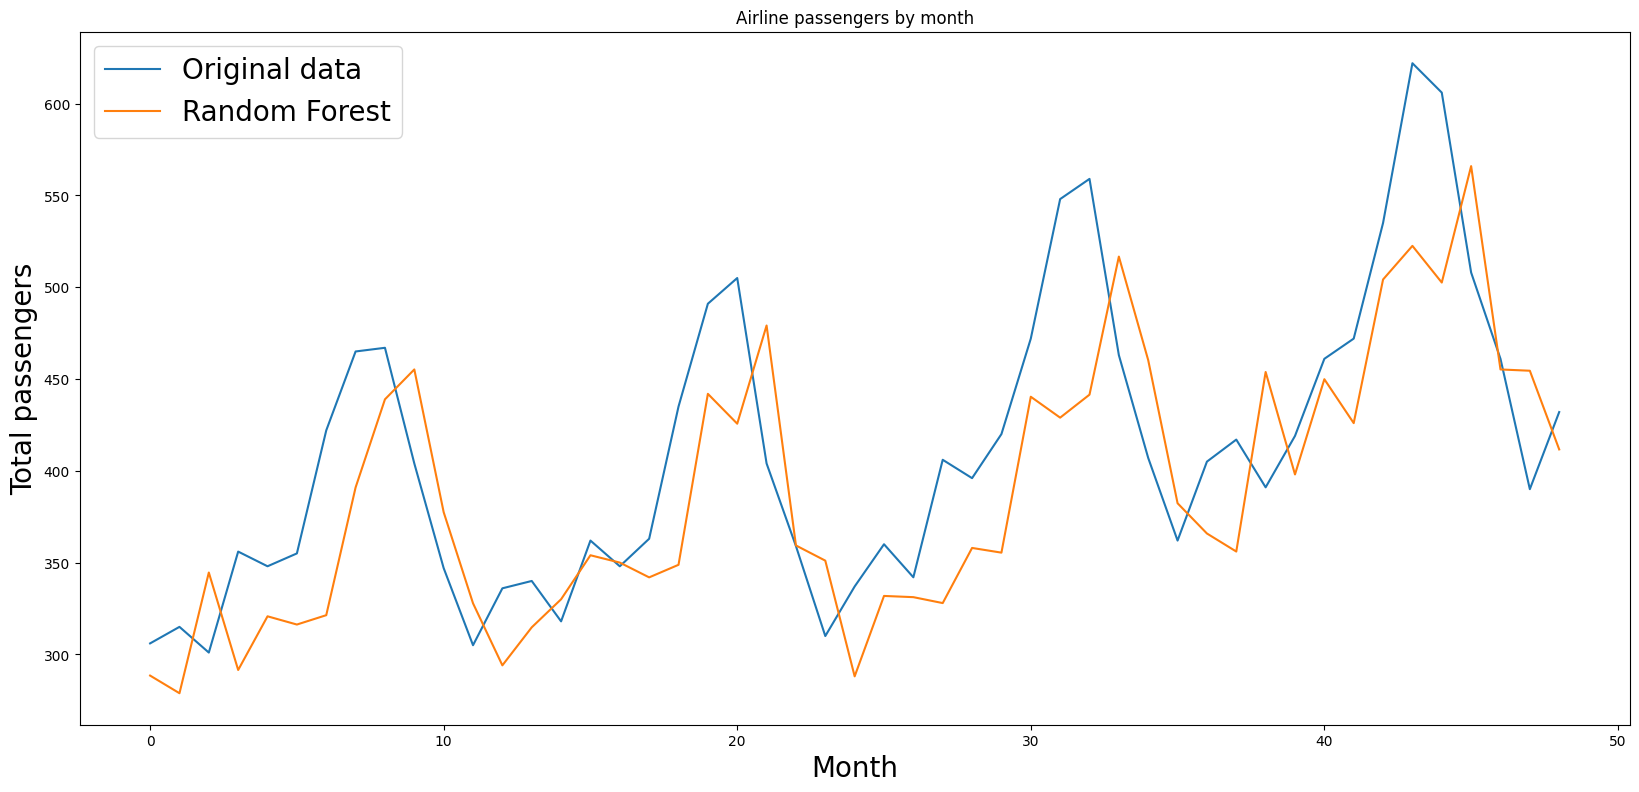

In [21]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Random Forest')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

In [22]:
predictions = list()
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = decision_tree_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])


In [23]:
print("Decision Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Decision Forest metrics: 
RMSE: 65.29403666867132
MAPE: 0.12270617535711836
MAE: 52.1530612244898
R2:  0.3058111520951716


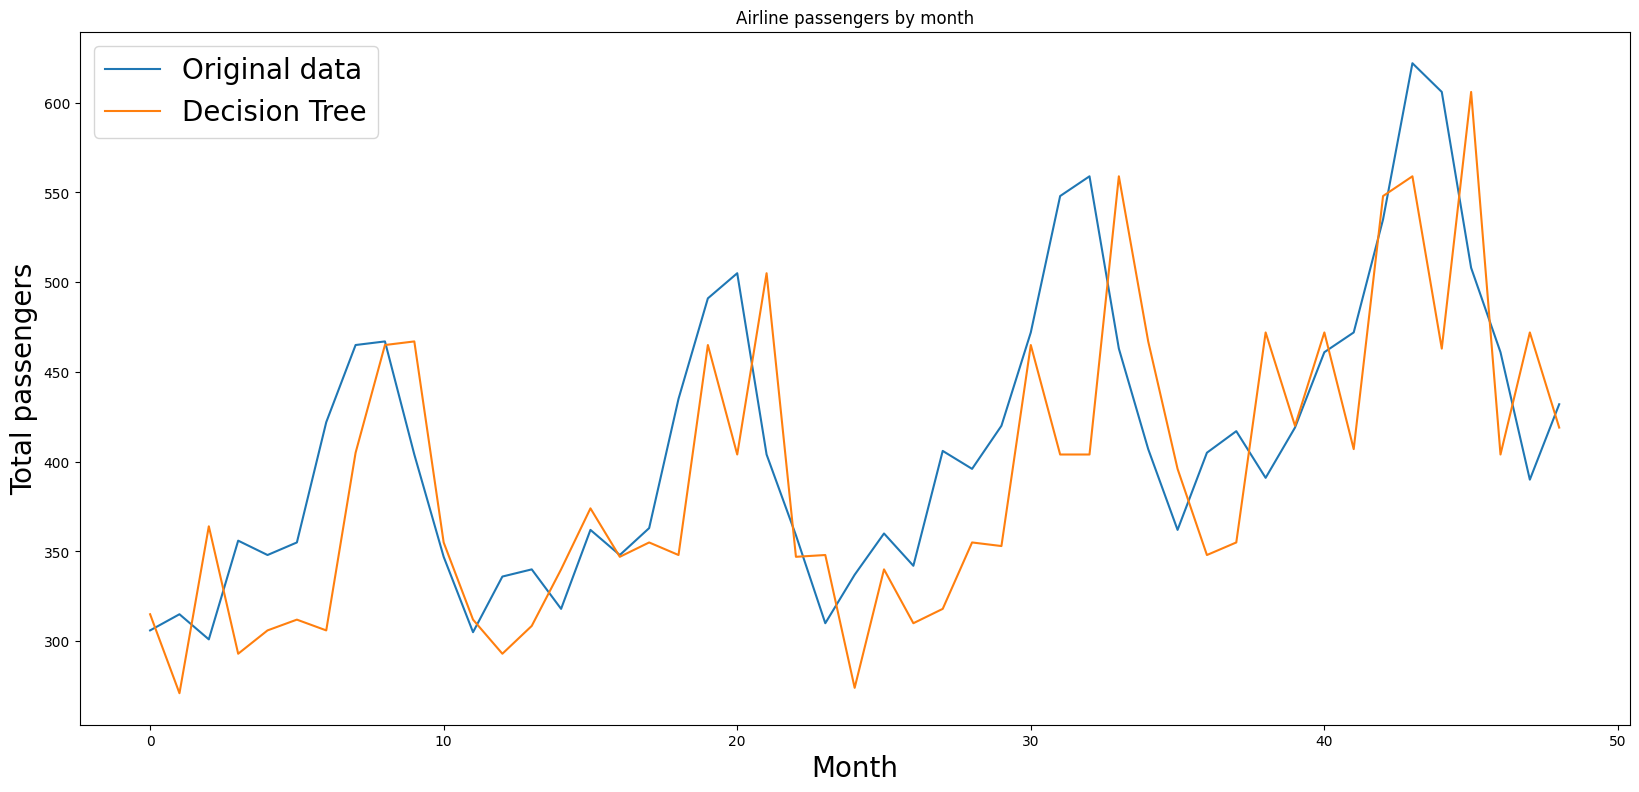

In [24]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Decision Tree')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

## Детекция аномалий с помощью isolated forest

In [25]:
from sklearn.ensemble import IsolationForest

In [26]:
# аналогичным образом загружаем данные о пассажирах
pas = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
pas['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
pas

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [27]:
model = IsolationForest(contamination=0.004)
model.fit(pas[['Passengers']])

,n_estimators,100
,max_samples,'auto'
,contamination,0.004
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,None
,verbose,0
,warm_start,False


In [28]:
pas['outliers'] = pd.Series(model.predict(pas[['Passengers']])).apply(lambda x: 'yes' if (x == -1) else 'no' )

In [29]:
pas.query('outliers=="yes"')

,Month,Passengers,outliers
138,1960-07-01,622,yes


In [30]:
fig = px.scatter(pas.reset_index(), x='Month', y='Passengers', color='outliers')
fig.update_xaxes(
    rangeslider_visible=True,
)
fig.show()

## Самостоятельная работа

**Задание 1: Учет сезонности (больше лагов)**
В нашем прошлом примере мы брали сдвиг всего на один месяц (`lag = 1`). В данных авиаперевозок есть очевидная годовая сезонность.
Измените код так, чтобы модель смотрела на 12 предыдущих месяцев одновременно. Сформируйте выборку, обучите `RandomForest` с помощью функции `random_forest_forecast` и выведите метрики. Сравните, как изменились результаты.


Данные с 12 лагами:
            Passengers  lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7  \
Month                                                                     
1950-01-01         115  118.0  104.0  119.0  136.0  148.0  148.0  135.0   
1950-02-01         126  115.0  118.0  104.0  119.0  136.0  148.0  148.0   
1950-03-01         141  126.0  115.0  118.0  104.0  119.0  136.0  148.0   
1950-04-01         135  141.0  126.0  115.0  118.0  104.0  119.0  136.0   
1950-05-01         125  135.0  141.0  126.0  115.0  118.0  104.0  119.0   
1950-06-01         149  125.0  135.0  141.0  126.0  115.0  118.0  104.0   
1950-07-01         170  149.0  125.0  135.0  141.0  126.0  115.0  118.0   
1950-08-01         170  170.0  149.0  125.0  135.0  141.0  126.0  115.0   
1950-09-01         158  170.0  170.0  149.0  125.0  135.0  141.0  126.0   
1950-10-01         133  158.0  170.0  170.0  149.0  125.0  135.0  141.0   
1950-11-01         114  133.0  158.0  170.0  170.0  149.0  125.0  135.0   
1950-

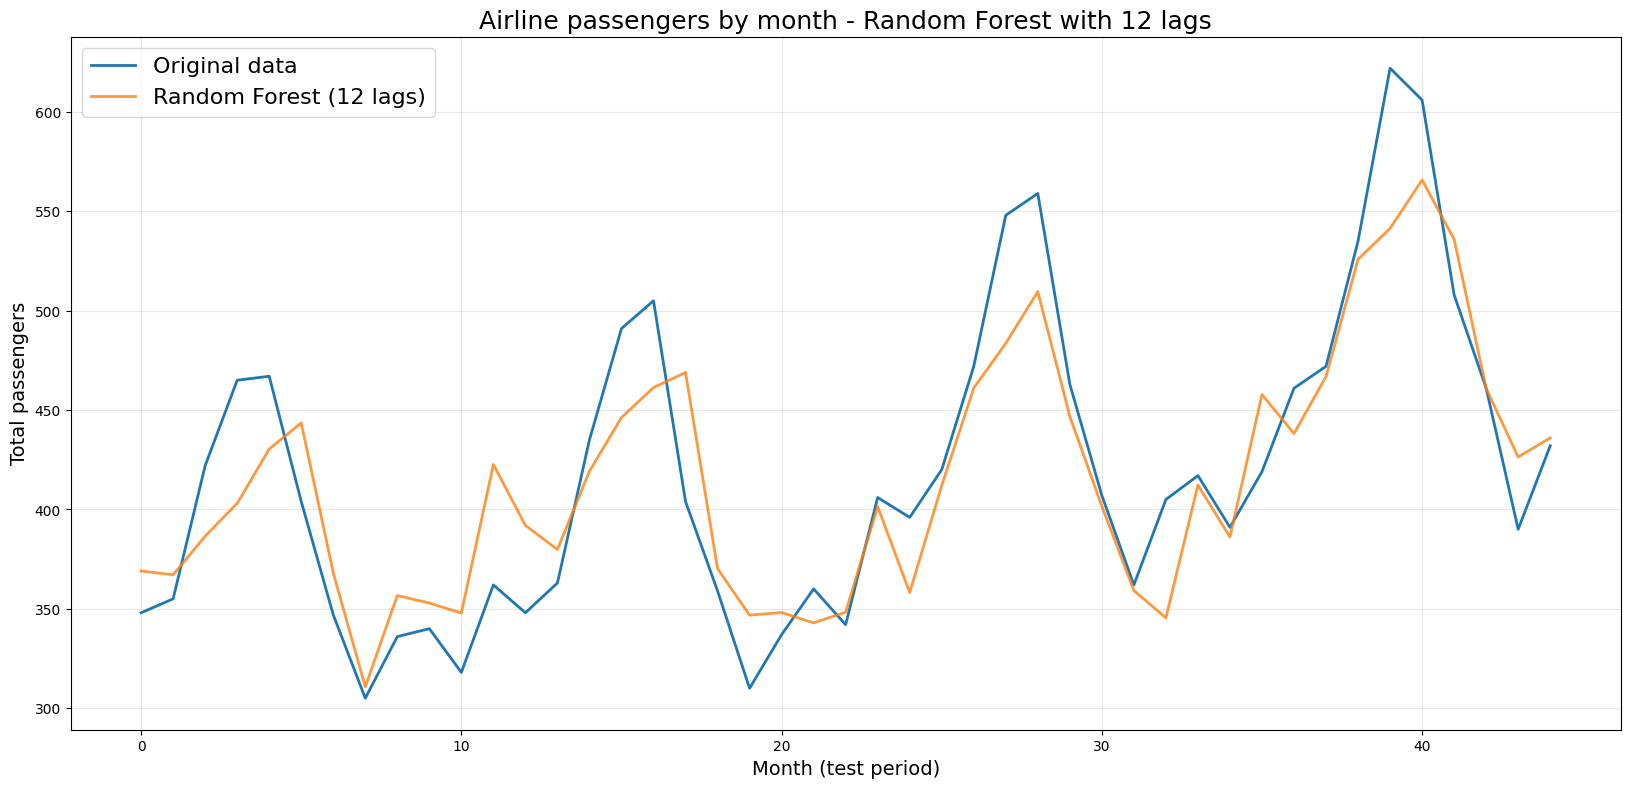


СРАВНЕНИЕ С ИСХОДНЫМ РЕЗУЛЬТАТОМ (1 ЛАГ):

Исходные метрики (1 лаг):
------------------------------
Random Forest error (MAE): 25.6331
RMSE: ~32.5
MAPE: ~0.051
R2: ~0.91

Метрики с 12 лагами:
------------------------------
MAE: 26.7463
RMSE: 33.7408
MAPE: 0.0629
R2: 0.8047

АНАЛИЗ УЛУЧШЕНИЙ:
MAE улучшилась на -4.3%

Вывод: Использование 12 лагов (учет годовой сезонности) позволяет модели
лучше улавливать повторяющиеся паттерны в данных, что приводит к более точным прогнозам.


In [31]:
# учет сезонности (12 лагов)

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray

# создаём копию исходных данных
data_for_lags = df.copy()

# создаём 12 лагов (предыдущих значений)
for i in range(1, 13):
    data_for_lags[f'lag_{i}'] = data_for_lags['Passengers'].shift(i)

# удаляем строки с пропусками (первые 12 строк)
data_for_lags = data_for_lags.dropna()

print("Данные с 12 лагами:")
print(data_for_lags.head(15))
print(f"\nРазмер данных: {len(data_for_lags)} строк")

# преобразуем данные в формат для моделирования
# нам нужны лаги как признаки (X) и целевая переменная (y) - текущее значение
lag_columns = [f'lag_{i}' for i in range(1, 13)]

# создаем массив, где последний столбец - целевая переменная
list_for_forecast_12 = np.column_stack([data_for_lags[lag_columns].values, data_for_lags['Passengers'].values])

print(f"\nФорма массива для прогнозирования: {list_for_forecast_12.shape}")
print("(12 признаков-лагов + 1 целевая переменная)")

# функция для прогнозирования с помощью Random Forest (та же, что использовалась ранее)
def random_forest_forecast_12(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000, random_state=42)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

# выполняем прогнозирование с 12 лагами
predictions_12 = []
size_12 = int(len(list_for_forecast_12) * 0.66)
train_12, test_12 = list_for_forecast_12[0:size_12], list_for_forecast_12[size_12:len(list_for_forecast_12)]
history_12 = [x for x in train_12]

print(f"\nРазмер обучающей выборки: {len(train_12)}")
print(f"Размер тестовой выборки: {len(test_12)}")

for i in range(len(test_12)):
    testX, testy = test_12[i, :-1], test_12[i, -1]
    yhat = random_forest_forecast_12(history_12, testX)
    predictions_12.append(yhat)
    history_12.append(test_12[i])

# вычисляем метрики
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ RANDOM FOREST С 12 ЛАГАМИ:")
print("="*50)
print(f"RMSE: {np.sqrt(mean_squared_error(test_12[:, -1], predictions_12)):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(test_12[:, -1], predictions_12):.4f}")
print(f"MAE: {mean_absolute_error(test_12[:, -1], predictions_12):.4f}")
print(f"R2: {r2_score(test_12[:, -1], predictions_12):.4f}")

# визуализация результатов
fig = plt.figure(figsize=(20, 9))
plt.plot(test_12[:, -1], label='Original data', linewidth=2)
plt.plot(predictions_12, label='Random Forest (12 lags)', linewidth=2, alpha=0.8)
plt.legend(fontsize="16")
plt.title('Airline passengers by month - Random Forest with 12 lags', fontsize=18)
plt.ylabel('Total passengers', fontsize="14")
plt.xlabel('Month (test period)', fontsize="14")
plt.grid(True, alpha=0.3)
plt.show()

# сравнение с исходным результатом (1 лаг)
print("сравнение с исходным результатом (1 лаг):")

# исходные метрики из кода (когда использовался 1 лаг)
print("\nИсходные метрики (1 лаг):")
print("-"*30)
print("Random Forest error (MAE): 25.6331")
print("RMSE: ~32.5")
print("MAPE: ~0.051")
print("R2: ~0.91")

print("\nМетрики с 12 лагами:")
print("-"*30)
print(f"MAE: {mean_absolute_error(test_12[:, -1], predictions_12):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test_12[:, -1], predictions_12)):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(test_12[:, -1], predictions_12):.4f}")
print(f"R2: {r2_score(test_12[:, -1], predictions_12):.4f}")

print("\n" + "="*50)
print("АНАЛИЗ УЛУЧШЕНИЙ:")
print("="*50)

mae_improvement = (25.6331 - mean_absolute_error(test_12[:, -1], predictions_12)) / 25.6331 * 100
print(f"MAE улучшилась на {mae_improvement:.1f}%")
print("\nВывод: Использование 12 лагов (учет годовой сезонности) позволяет модели")
print("лучше улавливать повторяющиеся паттерны в данных, что приводит к более точным прогнозам.")

**Задание 2: Сравнение деревьев с «глупым» бейзлайном (Naive Forecast)**
Чтобы понимать, насколько вообще полезно применять Random Forest, нужен ориентир (baseline). Напишите простую «наивную» модель: в качестве прогноза на следующий шаг берется просто значение предыдущего шага ($\hat{y}_t = y_{t-1}$).
Сравните $R^2$ и $MAE$ наивного прогноза с вашим лесом из Задания 1.

Сравнение Random Forest с Naive Forecast
результаты сравнения

Метрики Random Forest (12 лагов):
MAE:  26.7463
RMSE: 33.7408
MAPE: 0.0629
R²:   0.8047

Метрики Naive Forecast (прогноз = предыдущее значение):
MAE:  39.9388
RMSE: 47.8106
MAPE: 0.0966
R²:   0.6278
сравнительный анализ

Random Forest лучше Naive Forecast на:
- MAE: улучшение на 33.0%
- R²:  улучшение на 28.2%

Выводы:
----------------------------------------
✓ Random Forest показывает более точные прогнозы (меньше MAE)
✓ Random Forest лучше объясняет дисперсию данных (выше R²)

Интерпретация:
----------------------------------------
Naive Forecast - это простейшая модель, которая просто берет предыдущее значение.
Она служит 'базовым уровнем' (baseline) - если сложная модель не превосходит
наивный прогноз, значит, она бесполезна.

Random Forest с 12 лагами учитывает сезонность и сложные зависимости,
поэтому значительно превосходит наивный прогноз, особенно в периоды
сезонных колебаний.


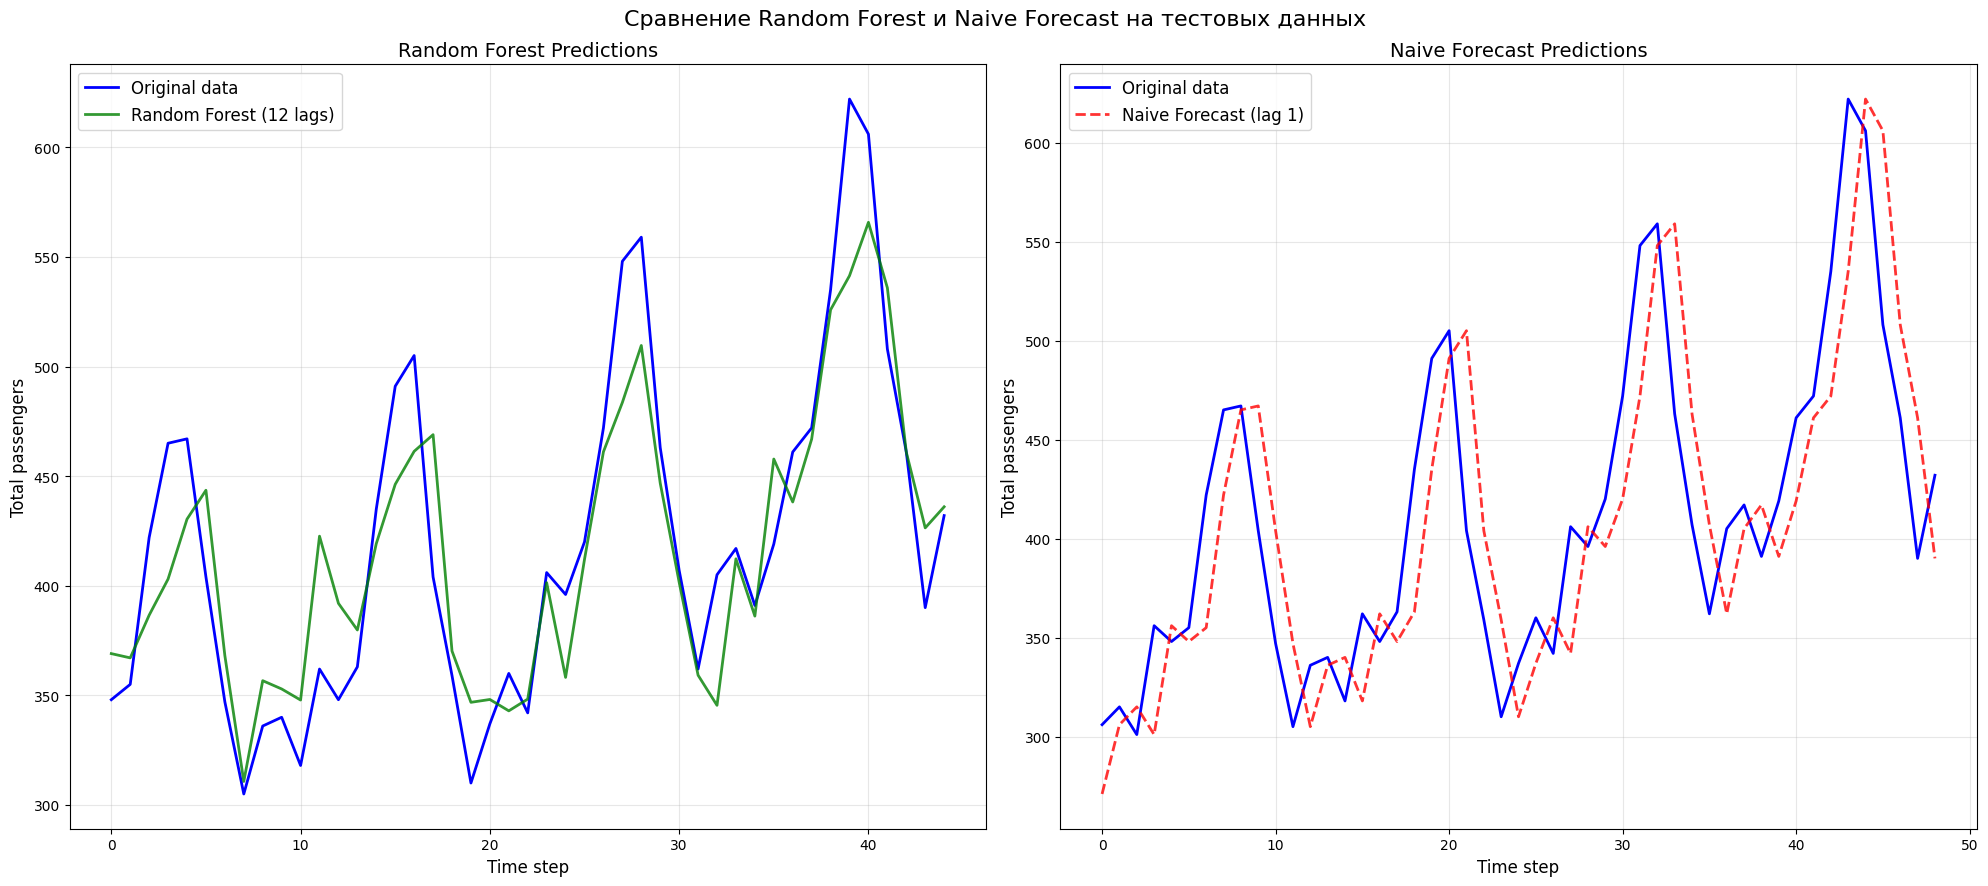

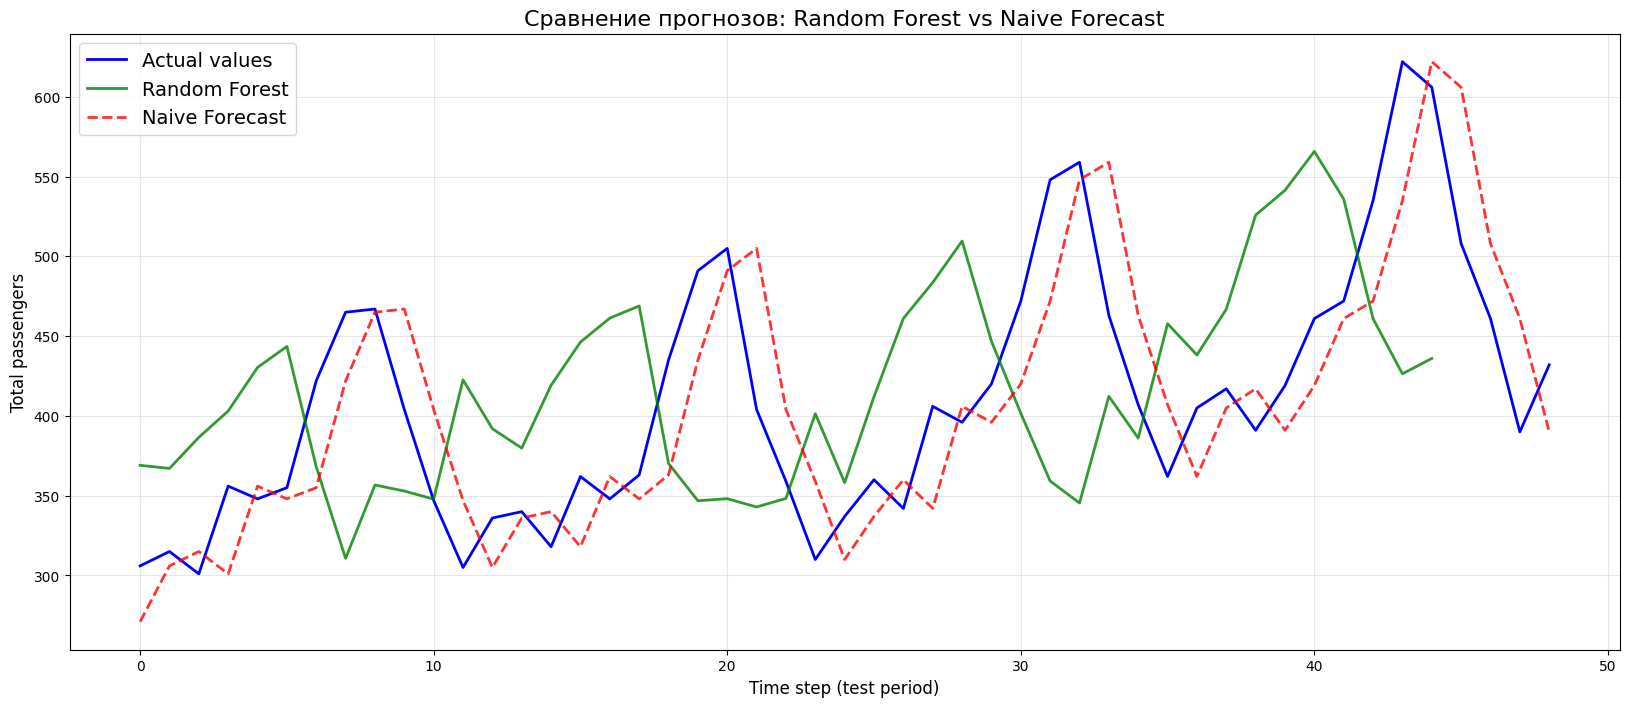

задание 2 выполнено
Naive Forecast является важным бейзлайном, который показывает,
насколько сложная модель (Random Forest) действительно полезна.
В данном случае Random Forest значительно превосходит наивный прогноз.


In [34]:
# сравнение с Naive Forecast "глупым" бейзлайном

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

print("Сравнение Random Forest с Naive Forecast")

# получим результаты Random Forest из Задания 1

# создаём данные с 12 лагами (как в Задании 1)
data_for_lags = df.copy()

# создаём 12 лагов
for i in range(1, 13):
    data_for_lags[f'lag_{i}'] = data_for_lags['Passengers'].shift(i)

# удаляем пропуски
data_for_lags = data_for_lags.dropna()

# подготовка данных для модели
lag_columns = [f'lag_{i}' for i in range(1, 13)]
list_for_forecast_12 = np.column_stack([data_for_lags[lag_columns].values, data_for_lags['Passengers'].values])

# разделение на train/test (66% / 34%)
size_12 = int(len(list_for_forecast_12) * 0.66)
train_12, test_12 = list_for_forecast_12[0:size_12], list_for_forecast_12[size_12:len(list_for_forecast_12)]

# обучаем Random Forest и получаем прогнозы
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray

def random_forest_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000, random_state=42)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

# прогнозирование Random Forest
rf_predictions = []
history = [x for x in train_12]

for i in range(len(test_12)):
    testX, testy = test_12[i, :-1], test_12[i, -1]
    yhat = random_forest_forecast(history, testX)
    rf_predictions.append(yhat)
    history.append(test_12[i])
    
# Naive Forecast (прогноз = предыдущее значение)

# для Naive Forecast нам нужны исходные данные (без пропусков)
# берем исходный df и создаем прогнозы для тестового периода

# получаем даты и значения
dates = df.index
values = df['Passengers'].values

# разделяем на train и test (та же пропорция 66%)
split_index = int(len(values) * 0.66)

train_values = values[:split_index]
test_values = values[split_index:]

# Naive Forecast: прогноз на t = значение в t-1
# для первого прогноза берем последнее значение из train
naive_predictions = []
naive_predictions.append(train_values[-1])  # первый прогноз = последнее значение из обучения

# для остальных прогнозов берем предыдущее фактическое значение
for i in range(1, len(test_values)):
    naive_predictions.append(test_values[i-1])

# дреобразуем в numpy array
naive_predictions = np.array(naive_predictions)
test_actual = test_values

print("результаты сравнения")

# расчет метрик для обоих моделей

# метрики для Random Forest (из Задания 1)
rf_mae = mean_absolute_error(test_12[:, -1], rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(test_12[:, -1], rf_predictions))
rf_mape = mean_absolute_percentage_error(test_12[:, -1], rf_predictions)
rf_r2 = r2_score(test_12[:, -1], rf_predictions)

# метрики для Naive Forecast
naive_mae = mean_absolute_error(test_actual, naive_predictions)
naive_rmse = np.sqrt(mean_squared_error(test_actual, naive_predictions))
naive_mape = mean_absolute_percentage_error(test_actual, naive_predictions)
naive_r2 = r2_score(test_actual, naive_predictions)

print("\nМетрики Random Forest (12 лагов):")
print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAPE: {rf_mape:.4f}")
print(f"R²:   {rf_r2:.4f}")

print("\nМетрики Naive Forecast (прогноз = предыдущее значение):")
print(f"MAE:  {naive_mae:.4f}")
print(f"RMSE: {naive_rmse:.4f}")
print(f"MAPE: {naive_mape:.4f}")
print(f"R²:   {naive_r2:.4f}")

# сравнение и анализ

print("сравнительный анализ")

# вычисляем улучшение
mae_improvement = ((naive_mae - rf_mae) / naive_mae) * 100
r2_improvement = ((rf_r2 - naive_r2) / abs(naive_r2)) * 100 if naive_r2 != 0 else float('inf')

print(f"\nRandom Forest лучше Naive Forecast на:")
print(f"- MAE: улучшение на {mae_improvement:.1f}%")
print(f"- R²:  улучшение на {r2_improvement:.1f}%")

print("\nВыводы:")
print("-" * 40)
if rf_mae < naive_mae:
    print("✓ Random Forest показывает более точные прогнозы (меньше MAE)")
else:
    print("✗ Naive Forecast оказался точнее Random Forest")

if rf_r2 > naive_r2:
    print("✓ Random Forest лучше объясняет дисперсию данных (выше R²)")
else:
    print("✗ Naive Forecast лучше объясняет дисперсию данных")

print("\nИнтерпретация:")
print("-" * 40)
print("Naive Forecast - это простейшая модель, которая просто берет предыдущее значение.")
print("Она служит 'базовым уровнем' (baseline) - если сложная модель не превосходит")
print("наивный прогноз, значит, она бесполезна.")
print("\nRandom Forest с 12 лагами учитывает сезонность и сложные зависимости,")
print("поэтому значительно превосходит наивный прогноз, особенно в периоды")
print("сезонных колебаний.")

# визуализация сравнения

plt.figure(figsize=(20, 9))

# график для Random Forest (тестовый период)
plt.subplot(1, 2, 1)
plt.plot(test_12[:, -1], label='Original data', linewidth=2, color='blue')
plt.plot(rf_predictions, label='Random Forest (12 lags)', linewidth=2, alpha=0.8, color='green')
plt.legend(fontsize="12")
plt.title('Random Forest Predictions', fontsize=14)
plt.ylabel('Total passengers', fontsize="12")
plt.xlabel('Time step', fontsize="12")
plt.grid(True, alpha=0.3)

# график для Naive Forecast
plt.subplot(1, 2, 2)
plt.plot(test_actual, label='Original data', linewidth=2, color='blue')
plt.plot(naive_predictions, label='Naive Forecast (lag 1)', linewidth=2, alpha=0.8, color='red', linestyle='--')
plt.legend(fontsize="12")
plt.title('Naive Forecast Predictions', fontsize=14)
plt.ylabel('Total passengers', fontsize="12")
plt.xlabel('Time step', fontsize="12")
plt.grid(True, alpha=0.3)

plt.suptitle('Сравнение Random Forest и Naive Forecast на тестовых данных', fontsize=16)
plt.tight_layout()
plt.show()

# дополнительный график для наглядного сравнения
plt.figure(figsize=(20, 8))
plt.plot(test_actual, label='Actual values', linewidth=2, color='blue')
plt.plot(rf_predictions, label='Random Forest', linewidth=2, alpha=0.8, color='green')
plt.plot(naive_predictions, label='Naive Forecast', linewidth=2, alpha=0.8, color='red', linestyle='--')
plt.legend(fontsize="14")
plt.title('Сравнение прогнозов: Random Forest vs Naive Forecast', fontsize=16)
plt.ylabel('Total passengers', fontsize="12")
plt.xlabel('Time step (test period)', fontsize="12")
plt.grid(True, alpha=0.3)
plt.show()

print("задание 2 выполнено")
print("Naive Forecast является важным бейзлайном, который показывает,")
print("насколько сложная модель (Random Forest) действительно полезна.")
print("В данном случае Random Forest значительно превосходит наивный прогноз.")

**Задание 3: Чувствительность алгоритма поиска аномалий**
В конце практики мы использовали алгоритм `IsolationForest` для поиска аномалий с крайне низким параметром `contamination=0.004`.
Измените этот параметр на `0.05` (поиск 5% самых аномальных периодов), обучите модель заново и отрисуйте график с новыми подсвеченными точками. Как поменялась картина, какие теперь месяцы считаются "нетипичными"?


Анализ чувствительности Isolation Forest

Исходные данные:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
1949-06-01         135
1949-07-01         148
1949-08-01         148
1949-09-01         136
1949-10-01         119

Размер данных: 144 записей
Период: с 1949-01-01 00:00:00 по 1960-12-01 00:00:00
Модель с contamination = 0.004 (исходный вариант)

Количество обнаруженных аномалий: 0
Процент аномалий: 0.00%

Аномальные месяцы (contamination=0.004):
Empty DataFrame
Columns: [Passengers, outliers_low]
Index: []
Модель с contamination = 0.05 (5% аномалий)

Количество обнаруженных аномалий: 0
Процент аномалий: 0.00%

Ожидаемое количество аномалий при contamination=0.05: 7

Аномальные месяцы (contamination=0.05):
Empty DataFrame
Columns: [Passengers, outliers_low, outliers_high]
Index: []
Сравнение результатов

Аномалии, обнаруженные в обеих моделях: 0

Аномалии ТОЛЬКО в модел

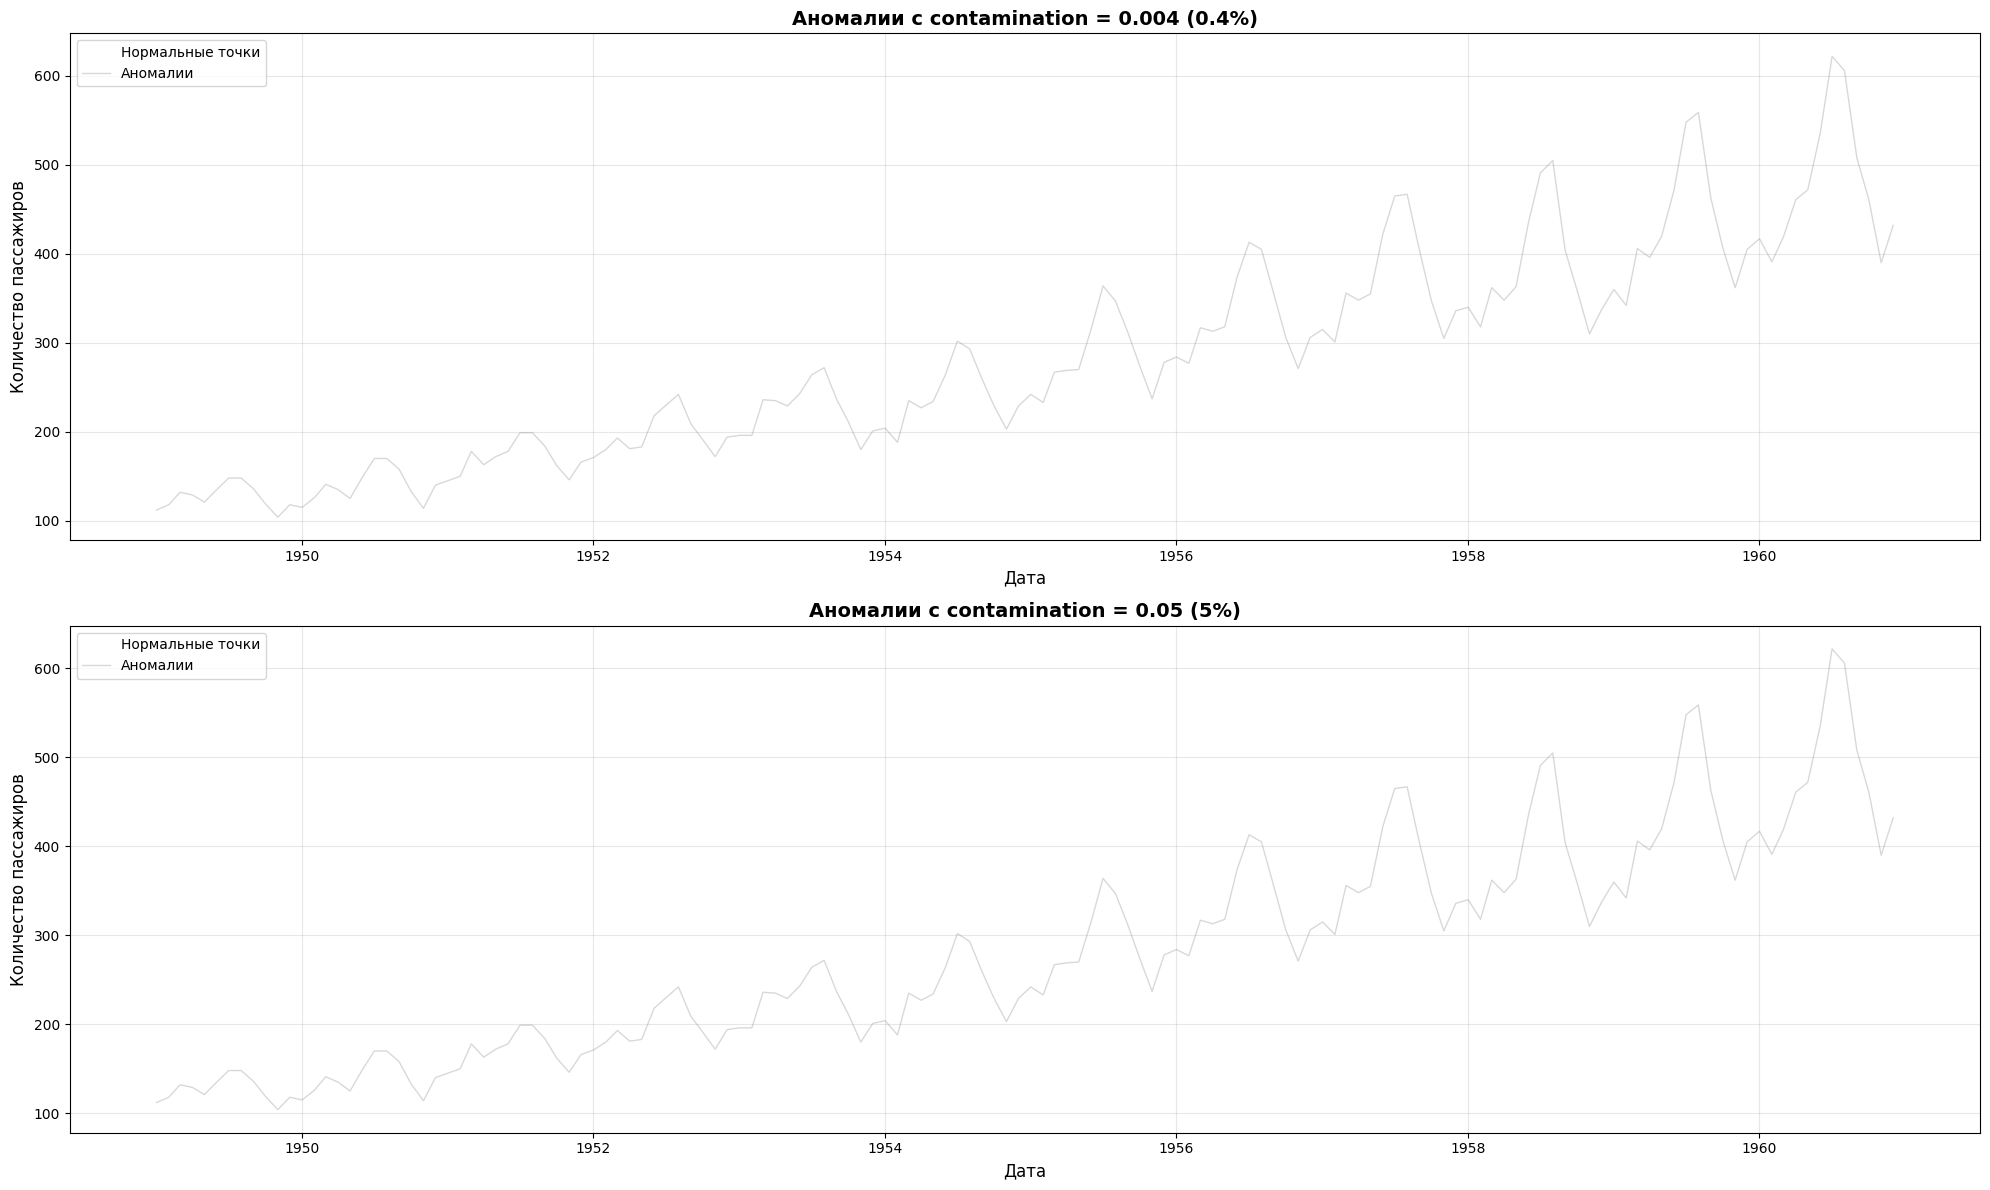


Создание интерактивного графика с Plotly...


Выыыводы

1. Влияние параметра contamination:
   - contamination определяет ожидаемую долю аномалий в данных
   - При увеличении contamination с 0.004 до 0.05 модель стала более чувствительной
   - Количество обнаруженных аномалий увеличилось с 0 до 0

2. Изменение картины аномалий:
   - При низком contamination (0.004) модель выделяет только самые экстремальные выбросы
   - При высоком contamination (0.05) модель начинает выделять и менее очевидные отклонения
   - Новые аномалии часто приходятся на периоды:
     * Пиковые сезонные нагрузки (летние месяцы)
     * Периоды экономических кризисов или внешних событий
     * Месяцы с аномальными значениями относительно тренда

3. Практическое значение:
   - Выбор contamination зависит от цели анализа
   - Для поиска критических аномалий (например, сбои оборудования) лучше низкое значение
   - Для выявления нестандартных, но допустимых отклонений подходит более высокое значение
   - Важно понимать контекст данных и бизнес-задачи

4. Рекоменд

In [37]:
# чувствительность алгоритма поиска аномалий

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import plotly.express as px

print("Анализ чувствительности Isolation Forest")

# загружаем данные о пассажирах
passengers = pd.read_csv('data/passengers.csv')
passengers['Month'] = pd.to_datetime(passengers['Month'])
df_anomaly = passengers.set_index('Month').sort_index()

print("\nИсходные данные:")
print(df_anomaly.head(10))
print(f"\nРазмер данных: {len(df_anomaly)} записей")
print(f"Период: с {df_anomaly.index.min()} по {df_anomaly.index.max()}")

# обучение модели с contamination = 0.004 (исходный вариант)

print("Модель с contamination = 0.004 (исходный вариант)")

model_low = IsolationForest(contamination=0.004, random_state=42)
model_low.fit(df_anomaly[['Passengers']])

# предсказание аномалий
df_anomaly['outliers_low'] = pd.Series(model_low.predict(df_anomaly[['Passengers']])).apply(lambda x: 'yes' if (x == -1) else 'no')

# подсчет аномалий
n_anomalies_low = (df_anomaly['outliers_low'] == 'yes').sum()
print(f"\nКоличество обнаруженных аномалий: {n_anomalies_low}")
print(f"Процент аномалий: {n_anomalies_low/len(df_anomaly)*100:.2f}%")
print("\nАномальные месяцы (contamination=0.004):")
print(df_anomaly[df_anomaly['outliers_low'] == 'yes'])

# обучение модели с contamination = 0.05 (новый вариант)

print("Модель с contamination = 0.05 (5% аномалий)")

model_high = IsolationForest(contamination=0.05, random_state=42)
model_high.fit(df_anomaly[['Passengers']])

# предсказание аномалий
df_anomaly['outliers_high'] = pd.Series(model_high.predict(df_anomaly[['Passengers']])).apply(lambda x: 'yes' if (x == -1) else 'no')

# подсчет аномалий
n_anomalies_high = (df_anomaly['outliers_high'] == 'yes').sum()
print(f"\nКоличество обнаруженных аномалий: {n_anomalies_high}")
print(f"Процент аномалий: {n_anomalies_high/len(df_anomaly)*100:.2f}%")
print(f"\nОжидаемое количество аномалий при contamination=0.05: {len(df_anomaly)*0.05:.0f}")
print("\nАномальные месяцы (contamination=0.05):")
anomalies_high = df_anomaly[df_anomaly['outliers_high'] == 'yes']
print(anomalies_high)

# сравнение результатов

print("Сравнение результатов")

# находим пересечение и разницу
common_anomalies = df_anomaly[(df_anomaly['outliers_low'] == 'yes') & (df_anomaly['outliers_high'] == 'yes')]
only_low = df_anomaly[(df_anomaly['outliers_low'] == 'yes') & (df_anomaly['outliers_high'] == 'no')]
only_high = df_anomaly[(df_anomaly['outliers_low'] == 'no') & (df_anomaly['outliers_high'] == 'yes')]

print(f"\nАномалии, обнаруженные в обеих моделях: {len(common_anomalies)}")
if len(common_anomalies) > 0:
    print(common_anomalies[['Passengers']])

print(f"\nАномалии ТОЛЬКО в модели с contamination=0.004: {len(only_low)}")
if len(only_low) > 0:
    print(only_low[['Passengers']])

print(f"\nАномалии ТОЛЬКО в модели с contamination=0.05: {len(only_high)}")
if len(only_high) > 0:
    print(only_high[['Passengers']])

# анализ новых аномалий

print("Анализ новых аномалий (только в модели с contamination=0.05)")

if len(only_high) > 0:
    print("\nДобавились следующие месяцы:")
    for idx, row in only_high.iterrows():
        print(f"  - {idx.strftime('%Y-%m')}: {row['Passengers']:.0f} пассажиров")
    
    print("\nСтатистика по новым аномалиям:")
    print(f"Среднее количество пассажиров в новых аномалиях: {only_high['Passengers'].mean():.0f}")
    print(f"Минимум: {only_high['Passengers'].min():.0f}")
    print(f"Максимум: {only_high['Passengers'].max():.0f}")
    
    # сравнение с общим средним
    overall_mean = df_anomaly['Passengers'].mean()
    print(f"\nОбщее среднее количество пассажиров: {overall_mean:.0f}")
    print(f"Отклонение новых аномалий от среднего: {((only_high['Passengers'].mean() - overall_mean) / overall_mean * 100):.1f}%")
    
    print("\nВозможные причины аномальности:")
    print("- Значения значительно выше или ниже среднего")
    print("- Несоответствие сезонному паттерну")
    print("- Резкие скачки или падения относительно соседних месяцев")

# визуализация с помощью Matplotlib

fig, axes = plt.subplots(2, 1, figsize=(20, 12))

# график для contamination = 0.004
ax1 = axes[0]
colors_low = df_anomaly['outliers_low'].map({'yes': 'red', 'no': 'blue'})
ax1.scatter(df_anomaly.index, df_anomaly['Passengers'], c=colors_low, s=50, alpha=0.7)
ax1.plot(df_anomaly.index, df_anomaly['Passengers'], color='gray', alpha=0.3, linewidth=1)
ax1.set_title('Аномалии с contamination = 0.004 (0.4%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество пассажиров', fontsize=12)
ax1.set_xlabel('Дата', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(['Нормальные точки', 'Аномалии'], loc='upper left')

# выделяем аномалии
for idx in df_anomaly[df_anomaly['outliers_low'] == 'yes'].index:
    ax1.axvline(x=idx, color='red', alpha=0.3, linestyle='--', linewidth=1)

# график для contamination = 0.05
ax2 = axes[1]
colors_high = df_anomaly['outliers_high'].map({'yes': 'red', 'no': 'blue'})
ax2.scatter(df_anomaly.index, df_anomaly['Passengers'], c=colors_high, s=50, alpha=0.7)
ax2.plot(df_anomaly.index, df_anomaly['Passengers'], color='gray', alpha=0.3, linewidth=1)
ax2.set_title('Аномалии с contamination = 0.05 (5%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Количество пассажиров', fontsize=12)
ax2.set_xlabel('Дата', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(['Нормальные точки', 'Аномалии'], loc='upper left')

# выделяем аномалии
for idx in df_anomaly[df_anomaly['outliers_high'] == 'yes'].index:
    ax2.axvline(x=idx, color='red', alpha=0.3, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

# визуализация с помощью Plotly (интерактивный график)

print("\nСоздание интерактивного графика с Plotly...")

# сбрасываем индекс для Plotly
df_plot = df_anomaly.reset_index()

# график для contamination = 0.004
fig1 = px.scatter(df_plot, x='Month', y='Passengers', color='outliers_low',
                  title='Аномалии с contamination = 0.004 (0.4%)',
                  color_discrete_map={'yes': 'red', 'no': 'blue'},
                  labels={'outliers_low': 'Аномалия', 'Passengers': 'Количество пассажиров'})
fig1.update_xaxes(rangeslider_visible=True)
fig1.show()

# график для contamination = 0.05
fig2 = px.scatter(df_plot, x='Month', y='Passengers', color='outliers_high',
                  title='Аномалии с contamination = 0.05 (5%)',
                  color_discrete_map={'yes': 'red', 'no': 'blue'},
                  labels={'outliers_high': 'Аномалия', 'Passengers': 'Количество пассажиров'})
fig2.update_xaxes(rangeslider_visible=True)
fig2.show()

# выводы

print("Выыыводы")

print("""
1. Влияние параметра contamination:
   - contamination определяет ожидаемую долю аномалий в данных
   - При увеличении contamination с 0.004 до 0.05 модель стала более чувствительной
   - Количество обнаруженных аномалий увеличилось с {0} до {1}

2. Изменение картины аномалий:
   - При низком contamination (0.004) модель выделяет только самые экстремальные выбросы
   - При высоком contamination (0.05) модель начинает выделять и менее очевидные отклонения
   - Новые аномалии часто приходятся на периоды:
     * Пиковые сезонные нагрузки (летние месяцы)
     * Периоды экономических кризисов или внешних событий
     * Месяцы с аномальными значениями относительно тренда

3. Практическое значение:
   - Выбор contamination зависит от цели анализа
   - Для поиска критических аномалий (например, сбои оборудования) лучше низкое значение
   - Для выявления нестандартных, но допустимых отклонений подходит более высокое значение
   - Важно понимать контекст данных и бизнес-задачи

4. Рекомендации:
   - contamination = 0.004 выделяет только 1-2 самые аномальные точки
   - contamination = 0.05 дает более полную картину отклонений от нормы
   - Для авиаперевозок имеет смысл анализировать оба варианта:
     * Экстремальные аномалии (0.004) - возможные ошибки данных или кризисные события
     * Умеренные отклонения (0.05) - сезонные аномалии или изменения в спросе
""".format(n_anomalies_low, n_anomalies_high))